<a href="https://colab.research.google.com/github/FurkanOznamli/Machine_Learning/blob/Denoising-Autoencoder-RBM/RBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


digits = load_digits()
X = digits.data
y = digits.target

print("Ham veri şekli:", X.shape)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Eğitim veri şekli:", X_train.shape)
print("Test veri şekli:", X_test.shape)


Ham veri şekli: (1797, 64)
Eğitim veri şekli: (1437, 64)
Test veri şekli: (360, 64)


In [11]:
from sklearn.neural_network import BernoulliRBM
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# RBM modelini oluştur
rbm = BernoulliRBM(n_components=64, learning_rate=0.05, n_iter=20, verbose=1)

print("RBM eğitimi başlıyor...")
rbm.fit(X_train)
print("RBM eğitimi tamamlandı.")


RBM eğitimi başlıyor...
[BernoulliRBM] Iteration 1, pseudo-likelihood = -26.07, time = 0.03s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -26.01, time = 0.04s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -25.44, time = 0.04s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -24.67, time = 0.04s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -23.99, time = 0.04s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -22.80, time = 0.04s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -22.52, time = 0.04s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -21.23, time = 0.04s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -21.96, time = 0.04s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -21.87, time = 0.06s
[BernoulliRBM] Iteration 11, pseudo-likelihood = -21.33, time = 0.05s
[BernoulliRBM] Iteration 12, pseudo-likelihood = -21.84, time = 0.04s
[BernoulliRBM] Iteration 13, pseudo-likelihood = -20.72, time = 0.05s
[BernoulliRBM] Iteration 14, pseudo-likelihood = -20.64, time = 0.04s
[Bern

In [12]:
import numpy as np
from sklearn.metrics import mean_squared_error

hidden_test = rbm.transform(X_test)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

reconstructed_test = sigmoid(np.dot(hidden_test, rbm.components_) + rbm.intercept_visible_)

# MSE hesapla
mse = mean_squared_error(X_test, reconstructed_test)
print("Rekonstrüksiyon MSE:", mse)


Rekonstrüksiyon MSE: 0.03855399541676649


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train_hidden = rbm.transform(X_train)
X_test_hidden = rbm.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_hidden, y_train)

y_pred = clf.predict(X_test_hidden)
acc = accuracy_score(y_test, y_pred)

print("RBM + Logistic Regression Test Doğruluğu:", acc)


RBM + Logistic Regression Test Doğruluğu: 0.8805555555555555


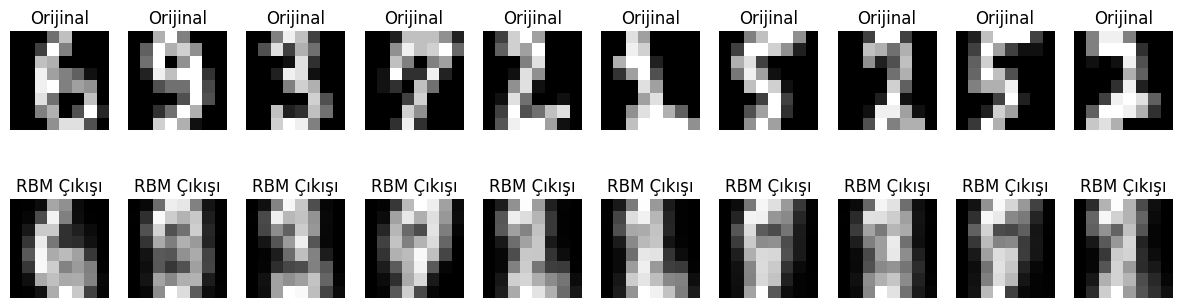

In [14]:
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(15, 4))

for i in range(n):
    # Orijinal
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap="gray")
    plt.title("Orijinal")
    plt.axis("off")

    # Rekonstrüksiyon
    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructed_test[i].reshape(8, 8), cmap="gray")
    plt.title("RBM Çıkışı")
    plt.axis("off")

plt.show()
